# Lecture 2 · Diagnose 

Following `1__Simple_Linear_Regression.pdf` (Kutner, Nachtsheim, Neter & Li, 2005, Ch. 1–2).

**Data:** `insurance.csv`, $n=1338$, $X$ = age (years), $Y$ = charges (USD).

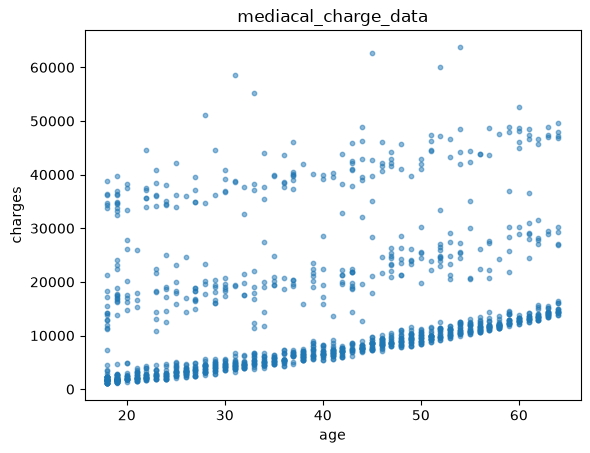

In [34]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

d = pd.read_csv('insurance.csv')
X = d['age'].to_numpy()
Y = d['charges'].to_numpy()
n = len(X)
d.head()

plt.scatter(X,Y, alpha=0.5, s= 10)
plt.xlabel('age')
plt.ylabel('charges')
plt.title('mediacal_charge_data')
plt.savefig('mediacal_charge_data.png')
plt.show()



## Descriptive quantities

The lecture first lists $\bar X$, $\bar Y$ and $\sum(X_i-\bar X)^2$ for the Toluca example.

In [2]:
Xbar, Ybar = X.mean(), Y.mean()
Sxx = ((X - Xbar)**2).sum()              # sum (Xi - Xbar)^2
Sxy = ((X - Xbar)*(Y - Ybar)).sum()
Syy = ((Y - Ybar)**2).sum()              # this becomes SSTO later
print(f'n    = {n}')
print(f'Xbar = {Xbar:.4f}   Ybar = {Ybar:,.2f}')
print(f'Sxx  = {Sxx:.4f}')

n    = 1338
Xbar = 39.2070   Ybar = 13,270.42
Sxx  = 263925.6540


## Least squares estimators (1.10a–b)

$$b_1=\frac{\sum(X_i-\bar X)(Y_i-\bar Y)}{\sum(X_i-\bar
X)^2},\qquad b_0=\bar Y-b_1\bar X$$

In [3]:
b1 = Sxy / Sxx
b0 = Ybar - b1 * Xbar
print(f'b1 = {b1:,.4f}    each additional age adds about {b1:,.0f} to mean charges')
print(f'b0 = {b0:,.4f}    mean response at X = 0 (is X = 0 within the scope of the model?)')
print(f'\nFitted regression function:  Yhat = {b0:,.2f} + {b1:,.2f} * X')

b1 = 257.7226    each additional age adds about 258 to mean charges
b0 = 3,165.8850    mean response at X = 0 (is X = 0 within the scope of the model?)

Fitted regression function:  Yhat = 3,165.89 + 257.72 * X


## Fitted values, residuals, and algebraic properties

In [4]:
Yhat = b0 + b1 * X
e = Y - Yhat                # residual e_i; distinct from the unknown error eps_i
print(f'sum(e_i)     = {e.sum():.6e}   (should be 0)')
print(f'sum(X_i e_i) = {(X*e).sum():.6e}   (should be 0)')
print(f'\nYhat at X = 5: {b0 + b1*5:,.2f}')

sum(e_i)     = 4.947651e-10   (should be 0)
sum(X_i e_i) = 1.862645e-09   (should be 0)

Yhat at X = 5: 4,454.50


## Estimating the error variance $\sigma^2$

$$SSE=\sum e_i^2,\qquad MSE=s^2=\frac{SSE}{n-2}$$


In [5]:
SSE = (e**2).sum()
MSE = SSE / (n - 2)
s   = np.sqrt(MSE)
print(f'SSE = {SSE:,.1f}')
print(f'MSE = {MSE:,.1f}   (df = {n-2})')
print(f's   = {s:,.2f}      typical deviation from the fitted line')

SSE = 178,544,029,385.2
MSE = 133,640,740.6   (df = 1336)
s   = 11,560.31      typical deviation from the fitted line


# Chapter 2

## Sampling distribution of $b_1$

$$\sigma^2\{b_1\}=\frac{\sigma^2}{\sum(X_i-\bar X)^2}
\quad\Longrightarrow\quad
s^2\{b_1\}=\frac{MSE}{\sum(X_i-\bar X)^2}$$

In [6]:
s2_b1 = MSE / Sxx
s_b1  = np.sqrt(s2_b1)
print(f's2{{b1}} = {s2_b1:,.2f}')
print(f's{{b1}}  = {s_b1:.4f}')

s2{b1} = 506.36
s{b1}  = 22.5024


## Confidence interval for $\beta_1$ (2.15)

$$b_1\pm t\!\left(1-\tfrac{\alpha}{2};\,n-2\right)s\{b_1\}$$

In [7]:
alpha = 0.05
tcrit = stats.t.ppf(1 - alpha/2, n - 2)
lo, hi = b1 - tcrit*s_b1, b1 + tcrit*s_b1
print(f't({1-alpha/2:.3f}; {n-2}) = {tcrit:.4f}')
print(f'95% CI for beta1: [{lo:,.2f}, {hi:,.2f}]')
print(f'\nWith 95% confidence, mean charges increases by between {lo:,.0f} and {hi:,.0f}')
print('per additional age.')

t(0.975; 1336) = 1.9617
95% CI for beta1: [213.58, 301.87]

With 95% confidence, mean charges increases by between 214 and 302
per additional age.


## Testing whether $\beta_1 = 0$

$$H_0:\beta_1=0\quad\text{vs.}\quad H_a:\beta_1\neq 0,\qquad t^*=\frac{b_1}{s\{b_1\}}$$

In [8]:
tstar = b1 / s_b1
pval  = 2 * stats.t.sf(abs(tstar), n - 2)
print(f't*            = {tstar:.4f}')
print(f'critical value = {tcrit:.4f}')
print(f'P-value        = {pval:.3e}')
print(f'\n|t*| > critical value  ->  reject H0: a linear association is present.')
print('Equivalently, the 95% CI for beta1 excludes 0.')

t*            = 11.4531
critical value = 1.9617
P-value        = 4.887e-29

|t*| > critical value  ->  reject H0: a linear association is present.
Equivalently, the 95% CI for beta1 excludes 0.


## Inference concerning $\beta_0$

$$s^2\{b_0\}=MSE\left[\frac{1}{n}+\frac{\bar X^2}{\sum(X_i-\bar X)^2}\right]$$

⚠️ Caution from the lecture: **$\beta_0$ has a direct meaning only if $X=0$ lies within the
scope of the model.**

In [9]:
s2_b0 = MSE * (1/n + Xbar**2 / Sxx)
s_b0  = np.sqrt(s2_b0)
print(f's{{b0}} = {s_b0:,.2f}')
print(f'95% CI for beta0: [{b0 - tcrit*s_b0:,.1f}, {b0 + tcrit*s_b0:,.1f}]')
print(f'\nObserved range of X: [{X.min()}, {X.max()}] — X = 0 is outside it,')
print('so b0 is a mathematical intercept, not the charges of a newborn.')

s{b0} = 937.15
95% CI for beta0: [1,327.4, 5,004.3]

Observed range of X: [18, 64] — X = 0 is outside it,
so b0 is a mathematical intercept, not the charges of a newborn.


## Two intervals: mean response vs. a new observation

$$s^2\{\hat Y_h\}=MSE\left[\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]
\qquad
s^2\{pred\}=MSE\left[\,\mathbf{1}+\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$$

**The difference is the extra $1$.** Predicting a new individual carries the uncertainty of
estimating the mean **plus** that individual's own scatter $\sigma^2$.

In [10]:
Xh = 45.0            # inside the observed range of X (18-64); Xh = 5 was not
Yh = b0 + b1*Xh
s_Yh   = np.sqrt(MSE * (1/n + (Xh-Xbar)**2/Sxx))
s_pred = np.sqrt(MSE * (1 + 1/n + (Xh-Xbar)**2/Sxx))
print(f'Xh = {Xh} years of age  ->  Yhat = {Yh:,.2f}\n')
print(f'Mean response E{{Yh}}   s = {s_Yh:8,.2f}   95% CI = [{Yh-tcrit*s_Yh:,.0f}, {Yh+tcrit*s_Yh:,.0f}]')
print(f'New observation Yh(new) s = {s_pred:8,.2f}   95% PI = [{Yh-tcrit*s_pred:,.0f}, {Yh+tcrit*s_pred:,.0f}]')
print(f'\nThe prediction interval is {(s_pred/s_Yh):.1f} times wider than the confidence interval.')

Xh = 45.0 years of age  ->  Yhat = 14,763.40

Mean response E{Yh}   s =   341.87   95% CI = [14,093, 15,434]
New observation Yh(new) s = 11,565.36   95% PI = [-7,925, 37,452]

The prediction interval is 33.8 times wider than the confidence interval.


## The two bands — narrowest at $\bar X$, flaring outward

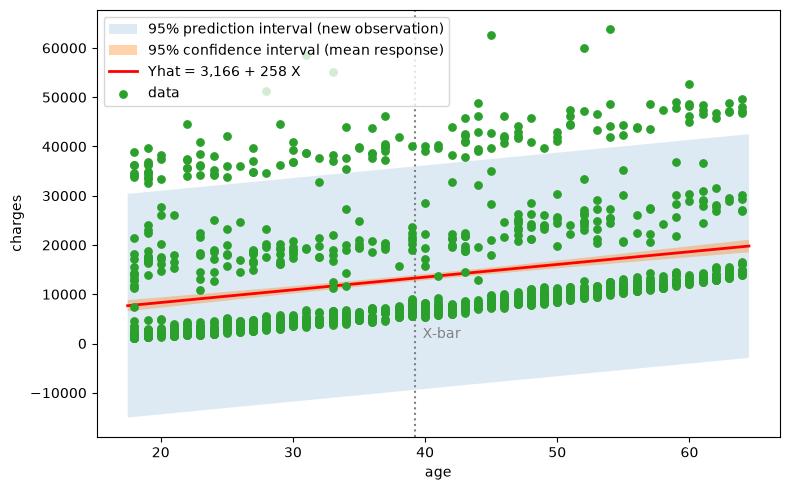

In [31]:
grid = np.linspace(X.min()-0.5, X.max()+0.5, 200)
fit  = b0 + b1*grid
se_m = np.sqrt(MSE * (1/n + (grid-Xbar)**2/Sxx))
se_p = np.sqrt(MSE * (1 + 1/n + (grid-Xbar)**2/Sxx))

plt.figure(figsize=(8,5))
plt.fill_between(grid, fit-tcrit*se_p, fit+tcrit*se_p, alpha=.15,
                 label='95% prediction interval (new observation)')
plt.fill_between(grid, fit-tcrit*se_m, fit+tcrit*se_m, alpha=.35,
                 label='95% confidence interval (mean response)')
plt.plot(grid, fit, 'r-', lw=2, label=f'Yhat = {b0:,.0f} + {b1:,.0f} X')
plt.scatter(X, Y, s=28, zorder=5, label='data')
plt.axvline(Xbar, ls=':', c='gray'); plt.text(Xbar, Y.min(), '  X-bar', c='gray')
plt.xlabel('age'); plt.ylabel('charges')
plt.legend(); plt.tight_layout(); 
plt.savefig('confident_intervel.png')
plt.show()

## ANOVA and the $F$ test

$$SSTO=SSR+SSE,\qquad F^*=\frac{MSR}{MSE}$$

In simple linear regression the $F$ test and the $t$ test are **identical**: $F^*=(t^*)^2$.

In [12]:
SSR   = ((Yhat - Ybar)**2).sum()
SSTO  = Syy
MSR   = SSR / 1
Fstar = MSR / MSE
Fcrit = stats.f.ppf(0.95, 1, n-2)

print(f'{"Source":<12}{"SS":>20}{"df":>5}{"MS":>20}{"F*":>10}')
print(f'{"Regression":<12}{SSR:>20,.0f}{1:>5}{MSR:>20,.0f}{Fstar:>10.2f}')
print(f'{"Error":<12}{SSE:>20,.0f}{n-2:>5}{MSE:>20,.0f}')
print(f'{"Total":<12}{SSTO:>20,.0f}{n-1:>5}')
print(f'\nF(0.95; 1, {n-2}) = {Fcrit:.2f}  ->  F* exceeds it, reject H0')
print(f'Equivalence check: (t*)^2 = {tstar**2:.2f}  ==  F* = {Fstar:.2f}')

Source                        SS   df                  MS        F*
Regression        17,530,192,183    1      17,530,192,183    131.17
Error            178,544,029,385 1336         133,640,741
Total            196,074,221,568 1337

F(0.95; 1, 1336) = 3.85  ->  F* exceeds it, reject H0
Equivalence check: (t*)^2 = 131.17  ==  F* = 131.17


## $R^2$, $r$, and the cautions

$$R^2=\frac{SSR}{SSTO}=1-\frac{SSE}{SSTO},\qquad r=\pm\sqrt{R^2}\ \ (\text{sign of } b_1)$$

In [13]:
R2 = SSR / SSTO
r  = np.sign(b1) * np.sqrt(R2)
print(f'R2 = {R2:.4f}   about {R2*100:.1f}% of the variation in charges is accounted for by age')
print(f'r  = {r:.4f}    (matches np.corrcoef: {np.corrcoef(X,Y)[0,1]:.6f})')

R2 = 0.0894   about 8.9% of the variation in charges is accounted for by age
r  = 0.2990    (matches np.corrcoef: 0.299008)


## Cross-check against `statsmodels`

In [14]:
import statsmodels.api as sm
fit_sm = sm.OLS(Y, sm.add_constant(X)).fit()
print(fit_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     131.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           4.89e-29
Time:                        10:58:14   Log-Likelihood:                -14415.
No. Observations:                1338   AIC:                         2.883e+04
Df Residuals:                    1336   BIC:                         2.884e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3165.8850    937.149      3.378      0.0

---

# Lecture 2 · Diagnostics and Remedial Measures


## The assumptions to be checked

$$Y_i=\beta_0+\beta_1X_i+\varepsilon_i,\qquad \varepsilon_i\ \overset{iid}{\sim}\ N(0,\sigma^2)$$

1. The regression function is **linear** in $X$.
2. The error terms have **constant variance** $\sigma^2$.
3. The error terms are **independent**.
4. The error terms are **normally distributed**.
5. No **outliers** unduly influence the fit.
6. No important **predictors** have been omitted.


## Residuals

$$e_i=Y_i-\hat Y_i,\qquad
\bar e=\frac1n\sum_i e_i=0,\qquad
s^2=\frac{\sum_i e_i^2}{n-2}=MSE$$

**Semistudentized residual:**
$$e_i^*=\frac{e_i}{\sqrt{MSE}}$$


In [16]:
e_star = e / np.sqrt(MSE)

print(f'ebar      = {e.mean():.6e}    (0 by construction)')
print(f's^2       = {(e**2).sum()/(n-2):,.1f}   == MSE = {MSE:,.1f}   -> {np.isclose((e**2).sum()/(n-2), MSE)}')
print(f'sqrt(MSE) = {np.sqrt(MSE):,.2f}')
print(f'\nmax |e*|  = {np.abs(e_star).max():.4f}')
print(f'cases with |e*| > 4: {(np.abs(e_star) > 4).sum()}   (Toluca had none, max |e*| = 2.1)')

flagged = np.where(np.abs(e_star) > 4)[0]
print(f'\n{"row":>5}{"age":>6}{"charges":>12}{"Yhat":>12}{"e":>12}{"e*":>8}')
for i in flagged:
    print(f'{i:>5}{X[i]:>6}{Y[i]:>12,.0f}{Yhat[i]:>12,.0f}{e[i]:>12,.0f}{e_star[i]:>8.2f}')

ebar      = 3.697796e-13    (0 by construction)
s^2       = 133,640,740.6   == MSE = 133,640,740.6   -> True
sqrt(MSE) = 11,560.31

max |e*|  = 4.1374
cases with |e*| > 4: 3   (Toluca had none, max |e*| = 2.1)

  row   age     charges        Yhat           e      e*
  543    54      63,770      17,083      46,688    4.04
  577    31      58,571      11,155      47,416    4.10
 1300    45      62,593      14,763      47,829    4.14


Unlike Toluca, this data set **does** trigger the outlier flag. The flagged cases are all
on the **high** side — very large charges at ordinary ages. Note that assumption 5
(outliers) and assumption 6 (omitted predictors) are hard to tell apart from the residuals
alone: a group of cases that a missing variable would explain looks exactly like a cluster
of outliers.

## Six departures, detected in the residuals

| Departure | Main diagnostic | Typical remedy |
|---|---|---|
| Nonlinearity | residuals vs. $X$ / $\hat Y$ | transform $X$; add terms |
| Nonconstant variance | residuals vs. $X$ (megaphone) | transform $Y$; weighted LS |
| Correlated errors | sequence plot | time-series model |
| Non-normality | normal probability plot | transform $Y$; Box-Cox |
| Outliers | (semistudentized) residual plots | investigate; robust fit |
| Omitted predictor | residuals vs. other variables | add the predictor |

The lecture takes these in turn: **plots** first, then **formal tests**, then **remedies**.

## Residuals vs. $X$ and vs. fitted values

For simple regression the two plots carry **the same information**, because
$\hat Y_i=b_0+b_1X_i$ is a linear function of $X_i$ — the second plot is the first one
rescaled. Plotting against $\hat Y$ is the general-purpose version used in multiple
regression.

What we want to see: a **structureless cloud** around the zero line.

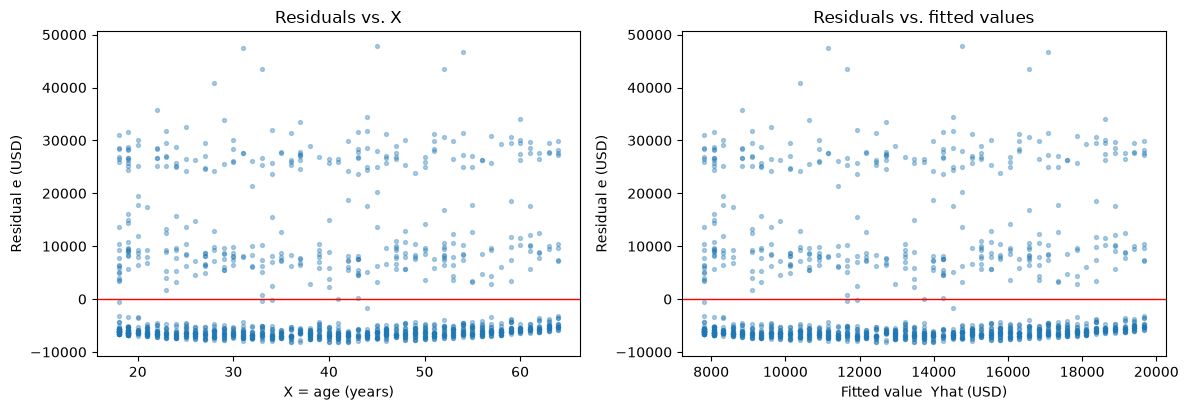

The two panels are the same plot: corr(X, Yhat) = 1.0000


In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, (h, lab) in zip(ax, [(X, 'X = age (years)'), (Yhat, 'Fitted value  Yhat (USD)')]):
    a.scatter(h, e, s=8, alpha=.35)
    a.axhline(0, c='r', lw=1)
    a.set_xlabel(lab); a.set_ylabel('Residual e (USD)')
ax[0].set_title('Residuals vs. X')
ax[1].set_title('Residuals vs. fitted values')
plt.tight_layout(); plt.show()

print(f'The two panels are the same plot: corr(X, Yhat) = {np.corrcoef(X, Yhat)[0,1]:.4f}')

The band is centred at zero and does not funnel outward — but it is clearly **split into
two sub-bands**, which is none of the four prototype patterns on the next slide.

## The four prototype patterns

(a) **random band** $\Rightarrow$ assumptions hold  
(b) **curvature** $\Rightarrow$ nonlinearity  
(c) **widening spread** $\Rightarrow$ nonconstant variance  

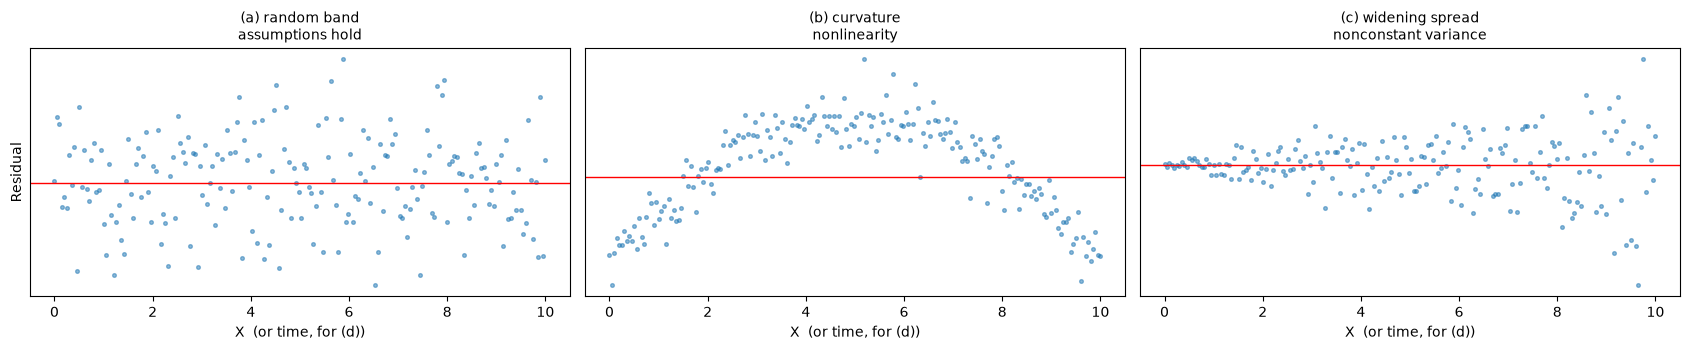

In [22]:
rng = np.random.default_rng(11)
xs  = np.linspace(0, 10, 200)

panels = [
    ('(a) random band\nassumptions hold',        rng.normal(0, 1, 200)),
    ('(b) curvature\nnonlinearity',              1.2 - 0.12*(xs - 5)**2 + rng.normal(0, .35, 200)),
    ('(c) widening spread\nnonconstant variance', rng.normal(0, 1, 200) * (0.2 + 0.35*xs))
]
fig, ax = plt.subplots(1, 3, figsize=(17, 3.6))
for a, (title, resid) in zip(ax, panels):
    a.scatter(xs, resid, s=7, alpha=.5)
    a.axhline(0, c='r', lw=1)
    a.set_title(title, fontsize=10)
    a.set_xlabel('X  (or time, for (d))'); a.set_yticks([])
ax[0].set_ylabel('Residual')
plt.tight_layout(); plt.show()

## Nonlinearity and nonconstant variance

**Slide 12.** Nonlinearity shows as a systematic $\cap$-shaped pattern; the residual plot
magnifies a departure the raw scatter can hide.

**Slide 13.** When the spread of $Y$ grows with $X$, the residuals fan out into a
**megaphone**. Ordinary least squares still gives **unbiased** $b_0,b_1$, but the standard
errors and intervals from Lecture 1 are **no longer valid**.

Both are read off a plot, so it is worth putting numbers next to the picture: the mean
residual per bin detects curvature, the standard deviation per bin detects a megaphone.

In [19]:
bins   = np.quantile(X, np.linspace(0, 1, 11))
idx    = np.clip(np.digitize(X, bins[1:-1]), 0, 9)
centre = np.array([X[idx == k].mean()   for k in range(10)])
m_bin  = np.array([e[idx == k].mean()   for k in range(10)])
s_bin  = np.array([e[idx == k].std(ddof=1) for k in range(10)])

print(f'{"bin":>4}{"n":>7}{"mean age":>11}{"mean e":>12}{"sd of e":>12}')
for k in range(10):
    print(f'{k:>4}{(idx==k).sum():>7}{centre[k]:>11.1f}{m_bin[k]:>12,.0f}{s_bin[k]:>12,.0f}')

print(f'\ncurvature check   corr(mean age, mean e) = {np.corrcoef(centre, m_bin)[0,1]:+.4f}')
print(f'megaphone check   corr(mean age, sd of e) = {np.corrcoef(centre, s_bin)[0,1]:+.4f}')
print(f'                  sd ratio last/first bin = {s_bin[-1]/s_bin[0]:.3f}')
print('\nNeither the bin means nor the bin spreads trend with age:')
print('no curvature (slide 12) and no megaphone (slide 13).')

 bin      n   mean age      mean e     sd of e
   0     69       18.0        -719      10,198
   1    181       20.6       1,029      12,255
   2    140       26.0        -292      11,131
   3    133       31.0        -163      11,825
   4    126       36.0        -195      12,090
   5    133       41.0        -614      10,786
   6    143       46.0         430      12,472
   7    143       51.0        -628      10,876
   8    131       56.0      -1,474      10,544
   9    139       61.4       1,823      12,238

curvature check   corr(mean age, mean e) = +0.0918
megaphone check   corr(mean age, sd of e) = +0.1069
                  sd ratio last/first bin = 1.200

Neither the bin means nor the bin spreads trend with age:
no curvature (slide 12) and no megaphone (slide 13).


## The normal probability plot

Order the residuals and plot each against its **expected value under normality**. Kutner's
expected value for the $k$-th smallest of $n$ residuals is

$$\sqrt{MSE}\;\;z\!\left(\frac{k-0.375}{n+0.25}\right)$$

Approximately normal errors $\Rightarrow$ points near a **straight line**. The plot is
accompanied by the **correlation test** between the ordered residuals and their expected
values (Kutner Table B.6). For Toluca the points fall close to the line, $r=0.99$, so
normality is supported.

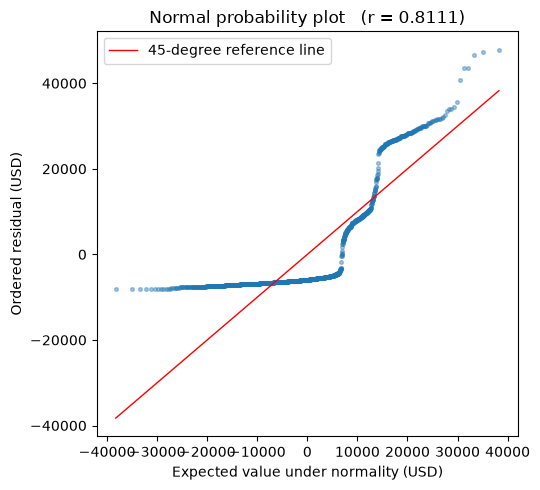

correlation between ordered residuals and expected values: r = 0.8111
Toluca, for comparison: r = 0.99 -> normality supported


In [30]:
k        = np.arange(1, n + 1)
expected = np.sqrt(MSE) * stats.norm.ppf((k - 0.375) / (n + 0.25))
ordered  = np.sort(e)
r_npp    = np.corrcoef(ordered, expected)[0, 1]

plt.figure(figsize=(5.5, 5))
plt.scatter(expected, ordered, s=7, alpha=.4)
lim = [expected.min(), expected.max()]
plt.plot(lim, lim, 'r-', lw=1, label='45-degree reference line')
plt.xlabel('Expected value under normality (USD)')
plt.ylabel('Ordered residual (USD)')
plt.title(f'Normal probability plot   (r = {r_npp:.4f})')
plt.legend(); plt.tight_layout(); 
plt.savefig('Normal_probability_plot.png')
plt.show()

print(f'correlation between ordered residuals and expected values: r = {r_npp:.4f}')
print(f'Toluca, for comparison: r = 0.99 -> normality supported')

Kutner's Table B.6 is not reproduced in the slides, so rather than quote a critical value
from memory the null distribution is simulated directly: draw normal samples of the same
size and record the same correlation.

In [22]:
rng_sim = np.random.default_rng(0)
def npp_corr(sample):
    m = len(sample)
    kk = np.arange(1, m + 1)
    return np.corrcoef(np.sort(sample), stats.norm.ppf((kk - 0.375) / (m + 0.25)))[0, 1]

B     = 2000
null_r = np.array([npp_corr(rng_sim.standard_normal(n)) for _ in range(B)])
crit   = np.percentile(null_r, 5)

print(f'simulated null, n = {n}, B = {B}')
print(f'  5th percentile (critical value at alpha = 0.05) = {crit:.4f}')
print(f'  smallest value observed in {B} normal samples   = {null_r.min():.4f}')
print(f'\nobserved r = {r_npp:.4f}')
print(f'-> below every one of the {B} draws: reject normality (p < {1/B:.4f})')

# sanity check of the simulation against the one value Kutner tabulates that is easy to recall
small = np.array([npp_corr(rng_sim.standard_normal(100)) for _ in range(2000)])
print(f'\nvalidation: simulated 5% critical value at n = 100 is {np.percentile(small,5):.4f},')
print('which matches the 0.987 given in Kutner Table B.6 for n = 100, alpha = 0.05.')

simulated null, n = 1338, B = 2000
  5th percentile (critical value at alpha = 0.05) = 0.9988
  smallest value observed in 2000 normal samples   = 0.9978

observed r = 0.8111
-> below every one of the 2000 draws: reject normality (p < 0.0005)



validation: simulated 5% critical value at n = 100 is 0.9871,
which matches the 0.987 given in Kutner Table B.6 for n = 100, alpha = 0.05.


## Non-normal signatures (Figure 3.9)

(a) **Heavy tails:** $S$-shape — the extremes bend away from the line.  
(b) **Right skew:** upward-curving pattern.  
(c) **Light tails:** inverted $S$.

Simulated below, then matched against the real plot.

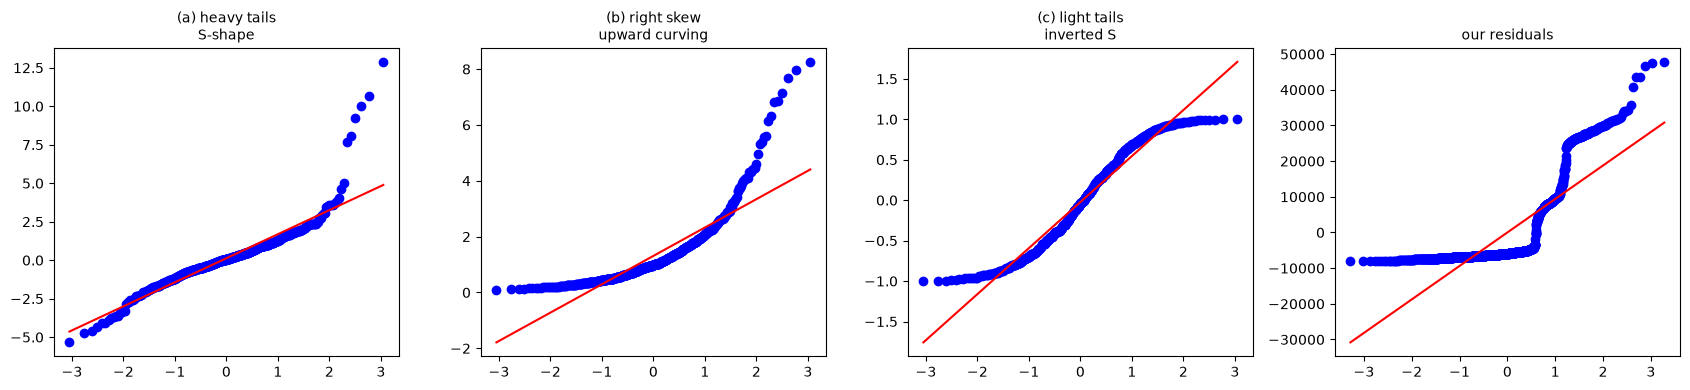

sample skewness of the residuals = +1.7327   (0 under normality)
The real plot curves upward: signature (b), right skew.


In [23]:
rng_sig = np.random.default_rng(17)
signatures = [
    ('(a) heavy tails\nS-shape',        rng_sig.standard_t(3, 600)),
    ('(b) right skew\nupward curving',  rng_sig.lognormal(0, .8, 600)),
    ('(c) light tails\ninverted S',     rng_sig.uniform(-1, 1, 600)),
]
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, (title, sample) in zip(ax, signatures):
    stats.probplot(sample, dist='norm', plot=a)
    a.set_title(title, fontsize=10); a.set_xlabel(''); a.set_ylabel('')
stats.probplot(e, dist='norm', plot=ax[3])
ax[3].set_title('our residuals', fontsize=10); ax[3].set_xlabel(''); ax[3].set_ylabel('')
plt.tight_layout(); plt.show()

print(f'sample skewness of the residuals = {stats.skew(e):+.4f}   (0 under normality)')
print('The real plot curves upward: signature (b), right skew.')

## Distribution of the residuals

A histogram (or box plot) complements the probability plot. Look for gross skewness,
**multiple modes**, or extreme values. With small $n$ the shape is noisy and must be read
cautiously — not an issue here, where $n=1338$.

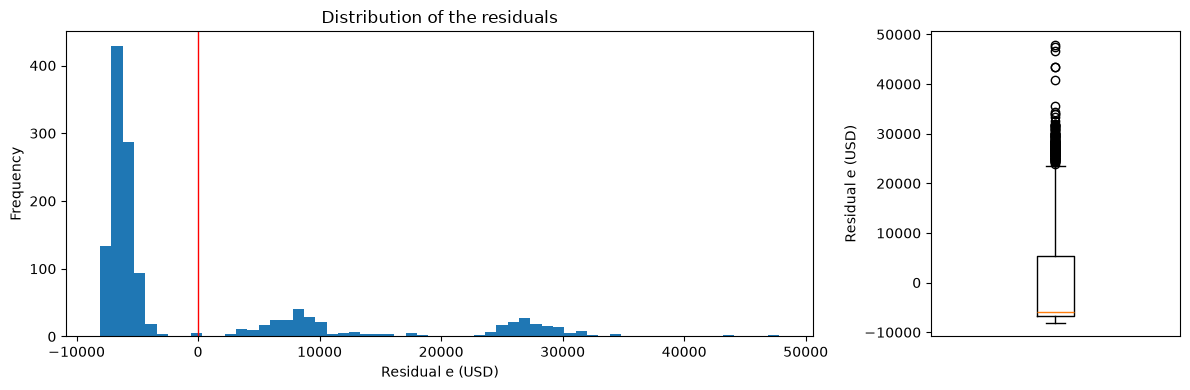

skewness = +1.7327      kurtosis (excess) = +1.8691
Shapiro-Wilk: W = 0.6577, p = 1.234e-45

The histogram is right-skewed AND has a long secondary lump rather than one mode.
Slide 18 lists multiple modes as a thing to look for: an omitted predictor
splitting the cases into groups produces exactly this.


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]})
ax[0].hist(e, bins=60)
ax[0].axvline(0, c='r', lw=1)
ax[0].set_xlabel('Residual e (USD)'); ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the residuals')
ax[1].boxplot(e); ax[1].set_xticks([]); ax[1].set_ylabel('Residual e (USD)')
plt.tight_layout(); plt.show()

print(f'skewness = {stats.skew(e):+.4f}      kurtosis (excess) = {stats.kurtosis(e):+.4f}')
print(f'Shapiro-Wilk: W = {stats.shapiro(e).statistic:.4f}, p = {stats.shapiro(e).pvalue:.3e}')
print('\nThe histogram is right-skewed AND has a long secondary lump rather than one mode.')
print('Slide 18 lists multiple modes as a thing to look for: an omitted predictor')
print('splitting the cases into groups produces exactly this.')